In [1]:
import pandas as pd

file_path = r"d:\Piyush\Downloads\backpain.csv"
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
data.head()

,pelvic_incidence,pelvic tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,pelvic_slope,Direct_tilt,thoracic_slope,cervical_tilt,sacrum_angle,scoliosis_slope,Status
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,0.744503,12.5661,14.5386,15.30468,-28.658501,43.5123,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0.415186,12.8874,17.5323,16.78486,-25.530607,16.1102,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0.474889,26.8343,17.4861,16.65897,-29.031888,19.2221,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0.369345,23.5603,12.7074,11.42447,-30.470246,18.8329,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0.543360,35.4940,15.9546,8.87237,-16.378376,24.9171,Abnormal


In [2]:
from PIL import Image
import pytesseract

# Path to the image file
image_path = r"D:\Piyush\Pictures\Instructions-Hands-on-Quiz-Decision-Trees.jpg"

# Load the image
image = Image.open(image_path)

# Perform OCR on the image
ocr_text = pytesseract.image_to_string(image)

# Print the extracted text
print(ocr_text)

Please download and import the dataset backpain.csv into Jupyter Notebook to attempt this quiz.

Problem Statement:

Low back pain is a major cause of morbidity in the developed world, affecting 40% of people at some point in their lives. Back pain can be caused by a variety of problems with any part of the complex,
interconnected network of spinal muscles, nerves, bones, disks, or tendons in the lumbar spine.

An irritation or problem with any of these structures can cause lower back pain and/or pain that radiates or is referred to other parts of the body. Many lower back problems also cause back muscle spasms,
which don't sound like much but can cause severe pain and disability.

While lower back pain is extremely common, the symptoms and severity of lower back pain vary greatly.

The spine of each patient was classified as - normal or abnormal, by practitioners, using the collected physical spine details/data.
Attribute information: -

(Please Note: Medical knowledge is not importan

In [4]:
# Exclude non-numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Find the highest correlations (excluding self-correlations)
highest_correlations = correlation_matrix.unstack().sort_values(ascending=False)

# Filter out self-correlations
highest_correlations = highest_correlations[highest_correlations < 1]

# Display the top correlations
print(highest_correlations.head())

pelvic_incidence       sacral_slope                0.814960
sacral_slope           pelvic_incidence            0.814960
pelvic_incidence       lumbar_lordosis_angle       0.717282
lumbar_lordosis_angle  pelvic_incidence            0.717282
pelvic_incidence       degree_spondylolisthesis    0.638743
dtype: float64


In [5]:
from sklearn.model_selection import train_test_split

# Encode the Status variable
data['Status'] = data['Status'].map({'Abnormal': 1, 'Normal': 0})

# Split the data into features (X) and target (y)
X = data.drop(columns=['Status'])
y = data['Status']

# Split the data into train and test sets (70:30 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Calculate the percentage of 0 and 1 classes in y_train
class_distribution = y_train.value_counts(normalize=True) * 100
print(class_distribution)

Status
1    66.359447
0    33.640553
Name: proportion, dtype: float64


In [6]:
range_1 = y[y == 1].index.min(), y[y == 1].index.max()
range_0 = y[y == 0].index.min(), y[y == 0].index.max()

print("Range of 1:", range_1)
print("Range of 0:", range_0)

Range of 1: (0, 209)
Range of 0: (210, 309)


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

# Initialize a dictionary to store accuracy for each depth
depth_accuracies = {}

# Loop through depths from 1 to 8
for depth in range(1, 9):
    # Initialize the DecisionTreeClassifier with the current depth
    model = DecisionTreeClassifier(max_depth=depth, random_state=1)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store the accuracy in the dictionary
    depth_accuracies[depth] = accuracy

# Print the accuracies for each depth
for depth, acc in depth_accuracies.items():
    # Calculate recall
    recall = recall_score(y_test, y_pred)

    # Print depth, accuracy, and recall
    print(f"Depth: {depth}, Accuracy: {acc}, Recall: {recall}")

Depth: 1, Accuracy: 0.7956989247311828, Recall: 0.7878787878787878
Depth: 2, Accuracy: 0.8279569892473119, Recall: 0.7878787878787878
Depth: 3, Accuracy: 0.7634408602150538, Recall: 0.7878787878787878
Depth: 4, Accuracy: 0.8064516129032258, Recall: 0.7878787878787878
Depth: 5, Accuracy: 0.7741935483870968, Recall: 0.7878787878787878
Depth: 6, Accuracy: 0.7849462365591398, Recall: 0.7878787878787878
Depth: 7, Accuracy: 0.8064516129032258, Recall: 0.7878787878787878
Depth: 8, Accuracy: 0.7741935483870968, Recall: 0.7878787878787878


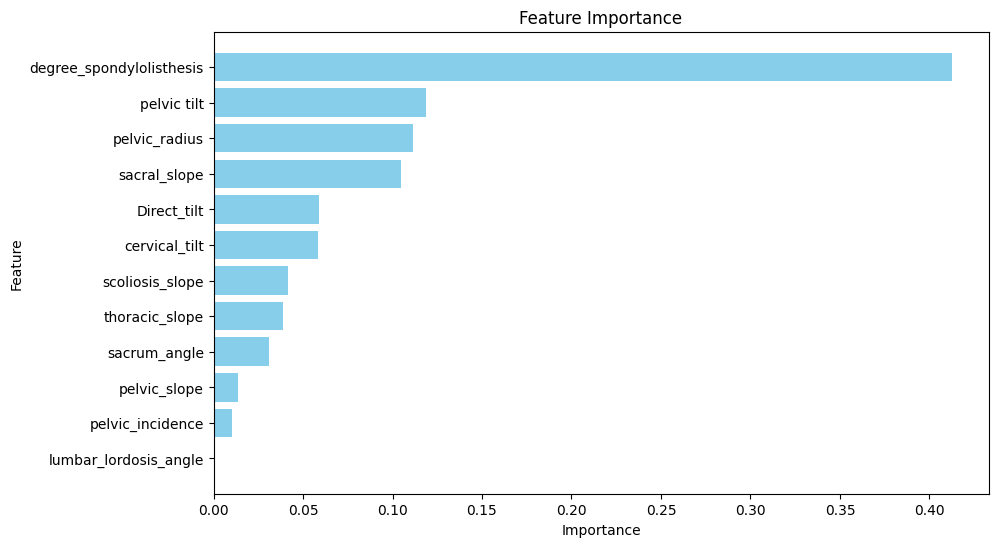

Two most important features: ['degree_spondylolisthesis', 'pelvic tilt']
Maximum recall on training set with top features: 0.9652777777777778


In [9]:
import numpy as np

import matplotlib.pyplot as plt

# Get feature importance from the model
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Select the two most important features
top_features = importance_df['Feature'].head(2).tolist()

# Train a new model using only the two most important features
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

model_top = DecisionTreeClassifier(max_depth=depth, random_state=1)
model_top.fit(X_train_top, y_train)

# Predict on the training set
y_train_pred_top = model_top.predict(X_train_top)

# Calculate recall on the training set
recall_top = recall_score(y_train, y_train_pred_top)

print(f"Two most important features: {top_features}")
print(f"Maximum recall on training set with top features: {recall_top}")

In [10]:
# Path to the image file
image_path = r"D:\Piyush\Pictures\Question5.jpg"

# Load the image
image = Image.open(image_path)

# Perform OCR on the image
ocr_text = pytesseract.image_to_string(image)

# Print the extracted text
print(ocr_text)

Attempt to improve the performance of the Decision tree using the list of hyperparameters and their values given.
¢ Maximum depth: [5,10,15, None],
¢ criterion: ['gini', ‘entropy’,
¢ splitter: ['best’, 'random']

¢ Compare the recall values of the models built to find the best one

Which of the following statements is/are True?

A) The best model selects the value of max_depth as 10
B) The best model selects the value of criterion as ‘gini’
C) The best model selects the value of splitter as 'random'
D) The best model selects the value of splitter as 'best'

E) The best model selects the value of max_depth as 5

F) The best model selects the value of criterion as 'entropy'



In [11]:
from sklearn.metrics import recall_score

# Define the hyperparameter grid
max_depth_values = [5, 10, 15, None]
criterion_values = ['gini', 'entropy']
splitter_values = ['best', 'random']

# Initialize variables to store the best model and its recall
best_recall = 0
best_params = {}

# Iterate through all combinations of hyperparameters
for max_depth in max_depth_values:
    for criterion in criterion_values:
        for splitter in splitter_values:
            # Initialize the DecisionTreeClassifier with the current combination of hyperparameters
            model = DecisionTreeClassifier(max_depth=max_depth, criterion=criterion, splitter=splitter, random_state=1)
            
            # Train the model
            model.fit(X_train, y_train)
            
            # Predict on the test set
            y_pred = model.predict(X_test)
            
            # Calculate recall
            recall = recall_score(y_test, y_pred)
            
            # Update the best model if the current recall is higher
            if recall > best_recall:
                best_recall = recall
                best_params = {'max_depth': max_depth, 'criterion': criterion, 'splitter': splitter}

# Print the best hyperparameters and the corresponding recall
print(f"Best Recall: {best_recall}")
print(f"Best Parameters: {best_params}")

Best Recall: 0.8787878787878788
Best Parameters: {'max_depth': 15, 'criterion': 'gini', 'splitter': 'random'}


In [12]:
from sklearn.metrics import f1_score

# Train a Decision Tree model with default parameters
default_model = DecisionTreeClassifier(random_state=1)
default_model.fit(X_train, y_train)

# Predict on the test set using the default model
y_pred_default = default_model.predict(X_test)

# Calculate recall and F1-score for the default model
recall_default = recall_score(y_test, y_pred_default)
f1_default = f1_score(y_test, y_pred_default)

# Predict on the test set using the best-selected model
y_pred_best = model.predict(X_test)

# Calculate recall and F1-score for the best-selected model
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

# Print the comparison of recall and F1-score
print(f"Default Model - Recall: {recall_default}, F1-Score: {f1_default}")
print(f"Best Model - Recall: {recall_best}, F1-Score: {f1_best}")

Default Model - Recall: 0.7878787878787878, F1-Score: 0.832
Best Model - Recall: 0.8484848484848485, F1-Score: 0.875
